In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import re

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

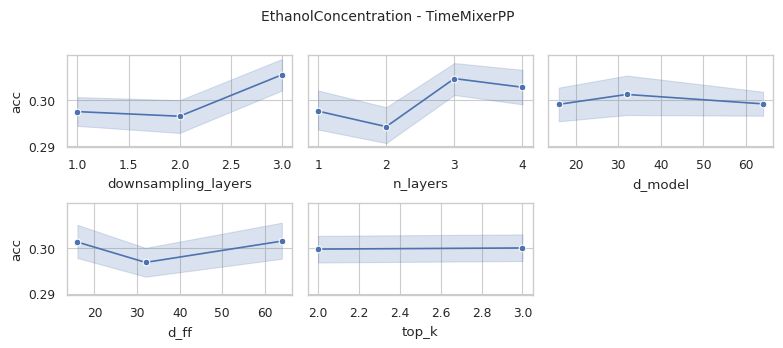

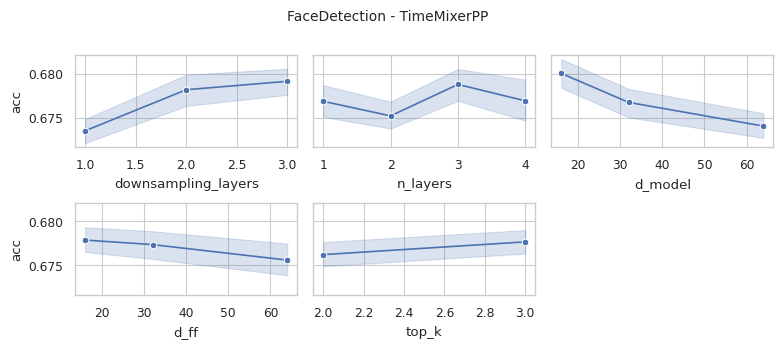

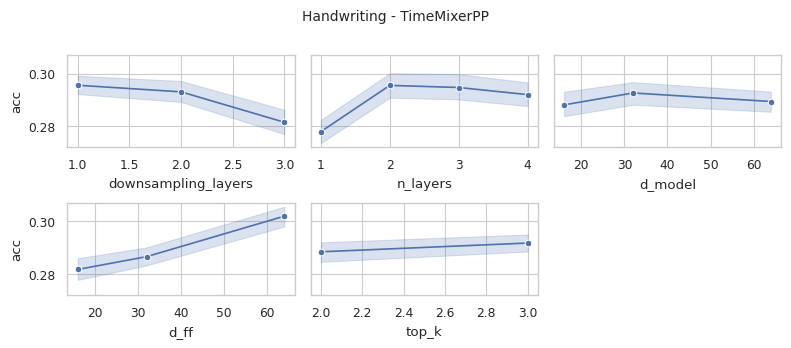

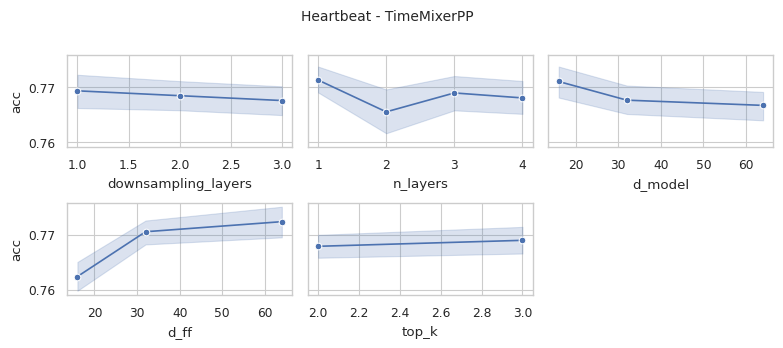

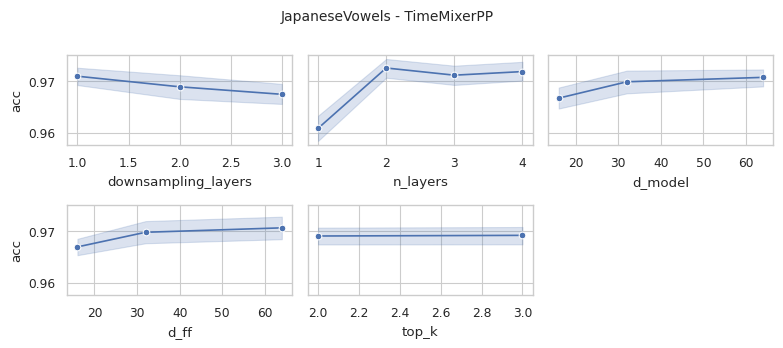

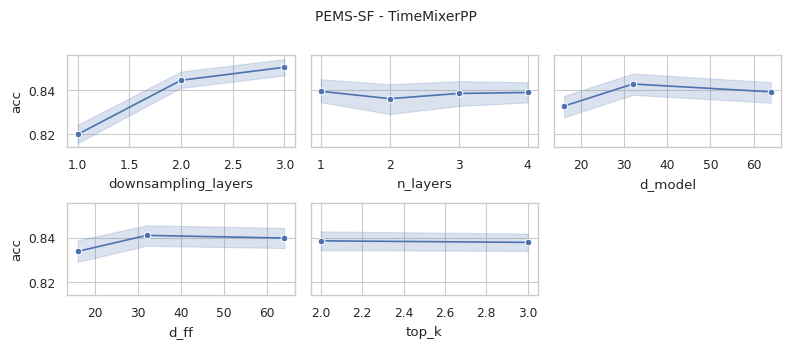

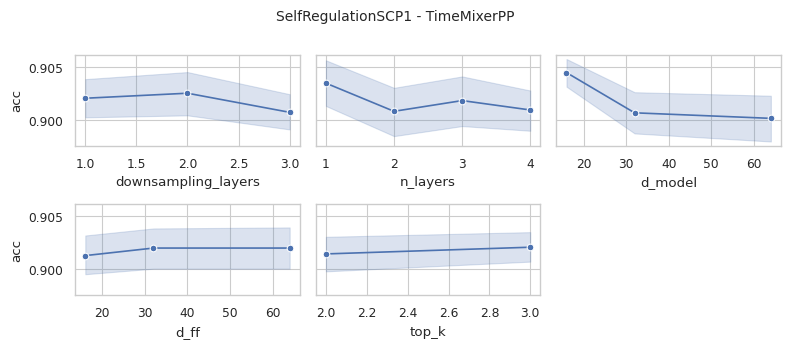

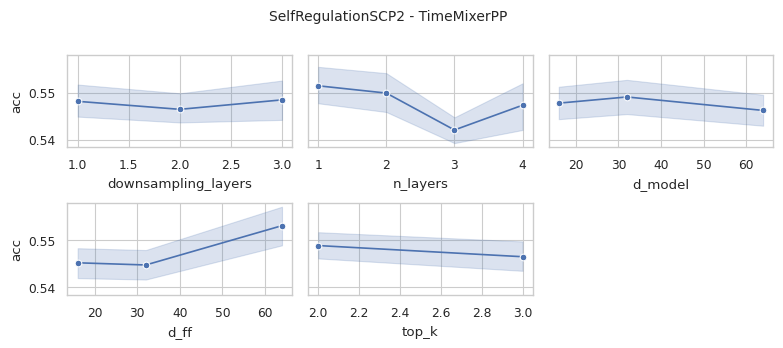

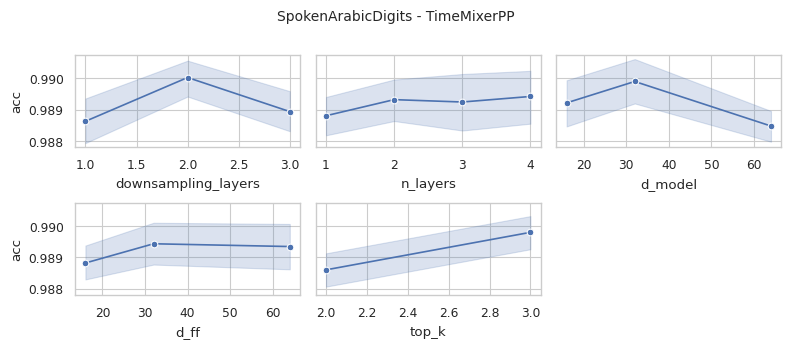

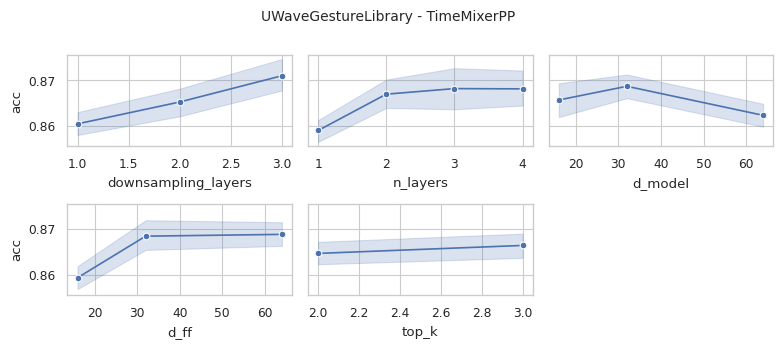

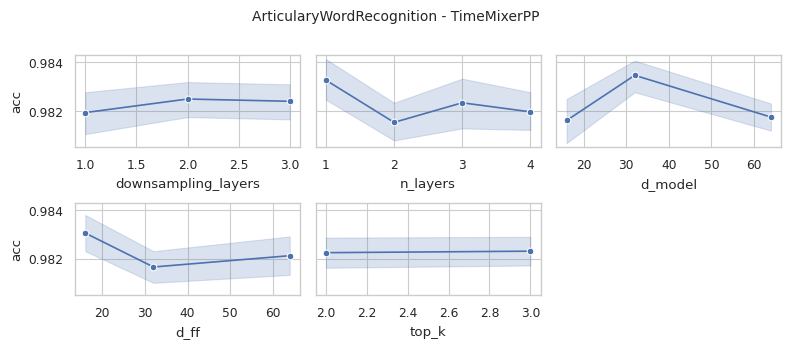

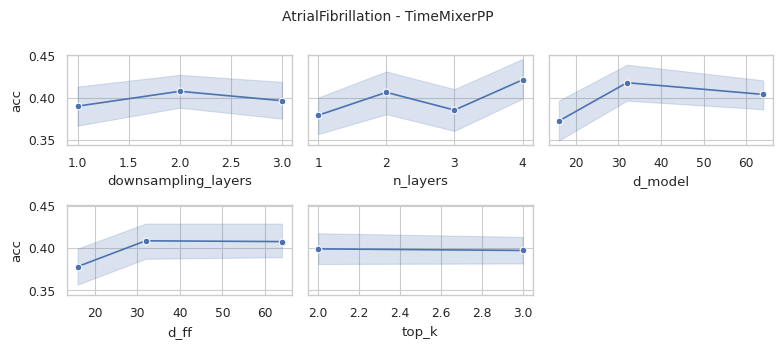

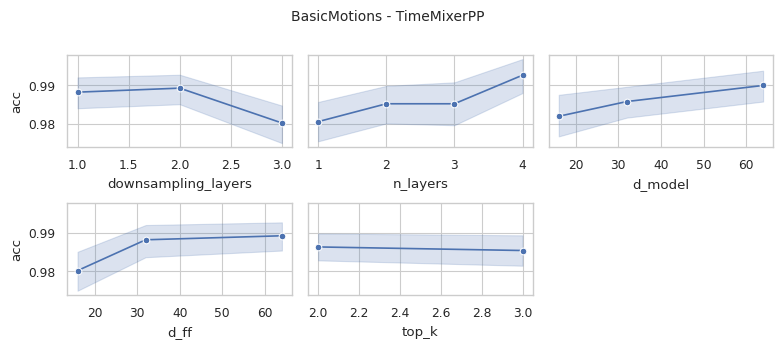

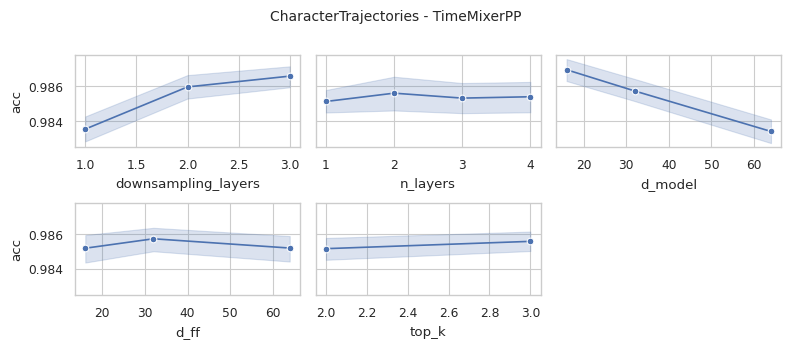

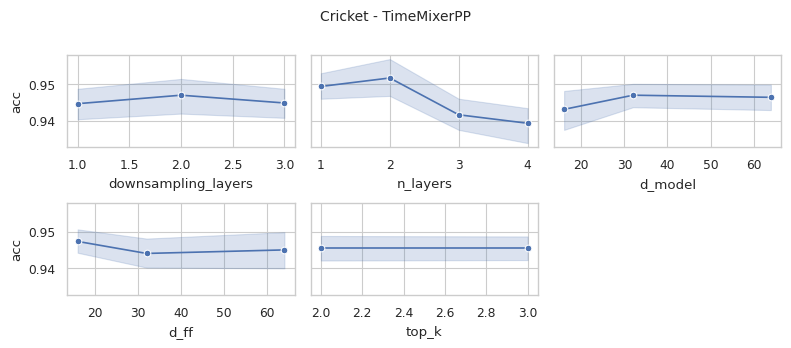

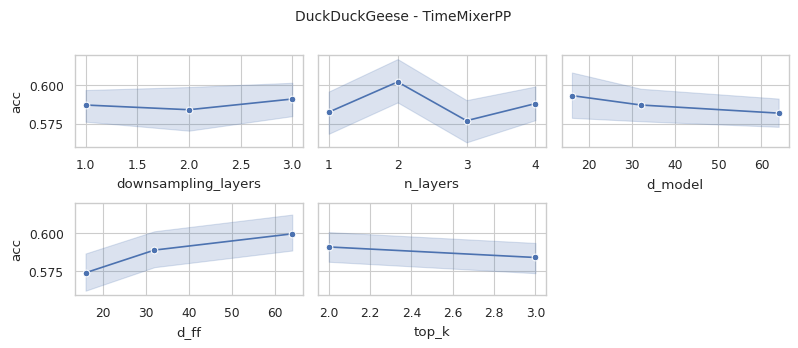

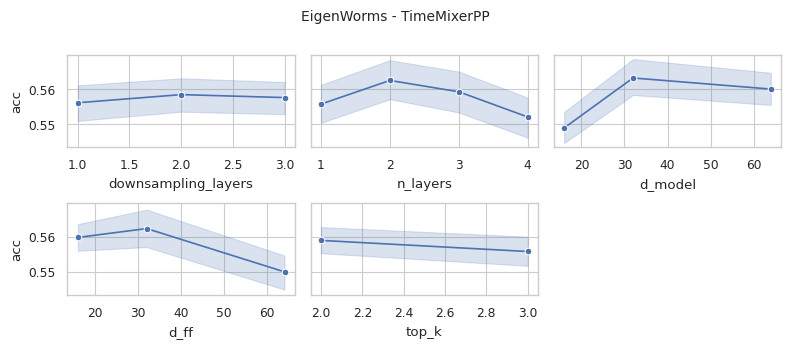

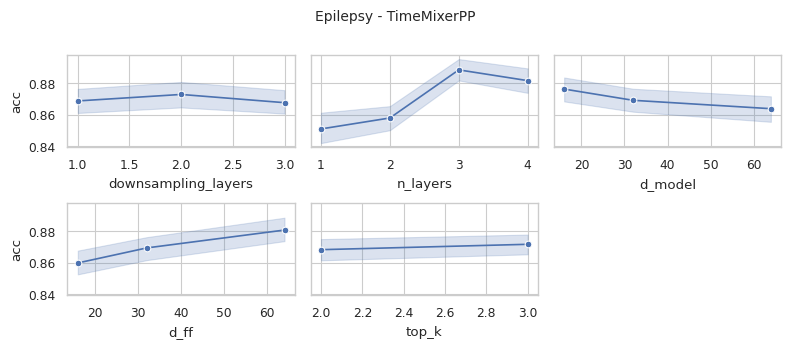

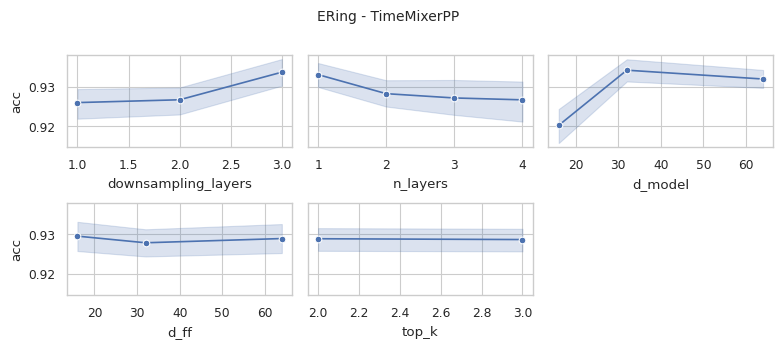

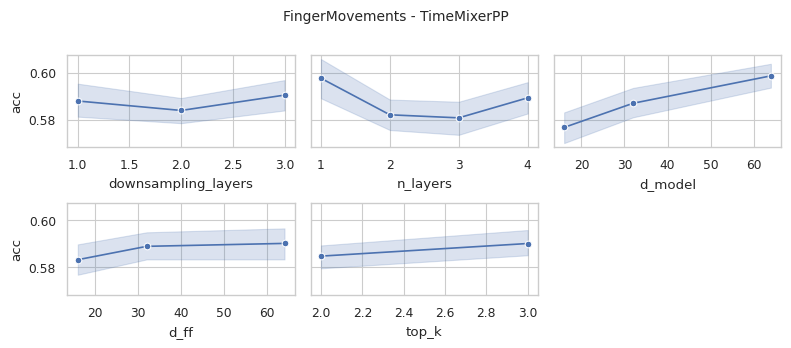

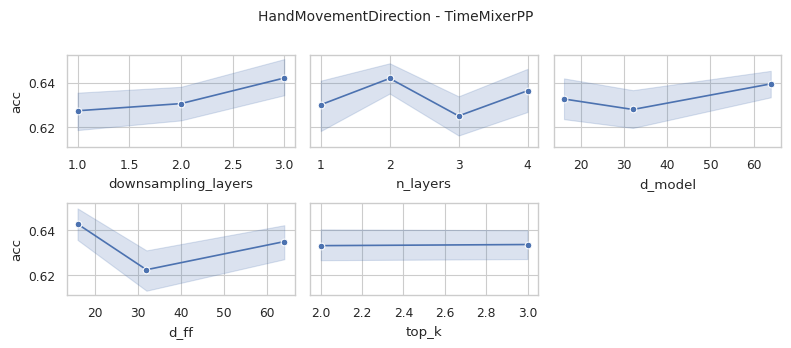

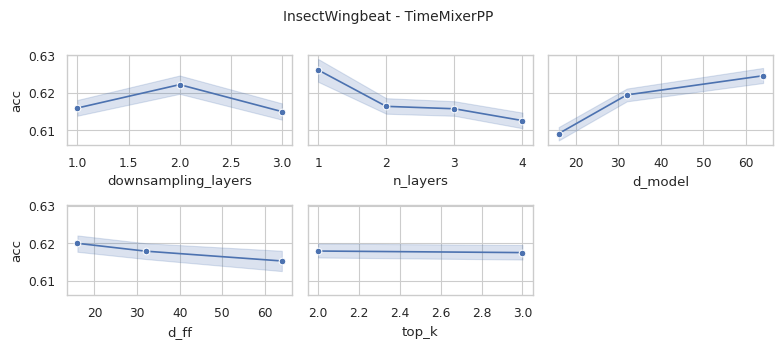

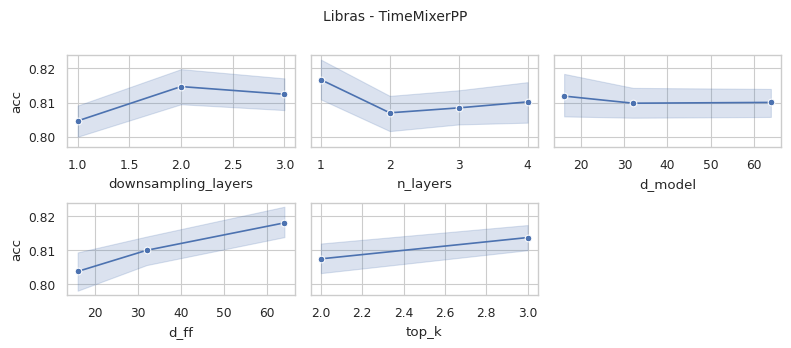

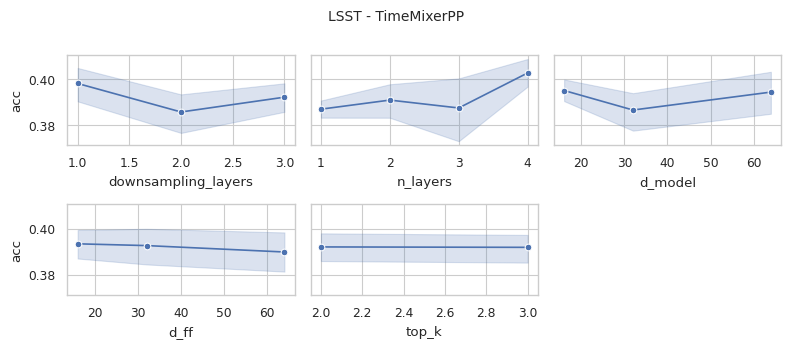

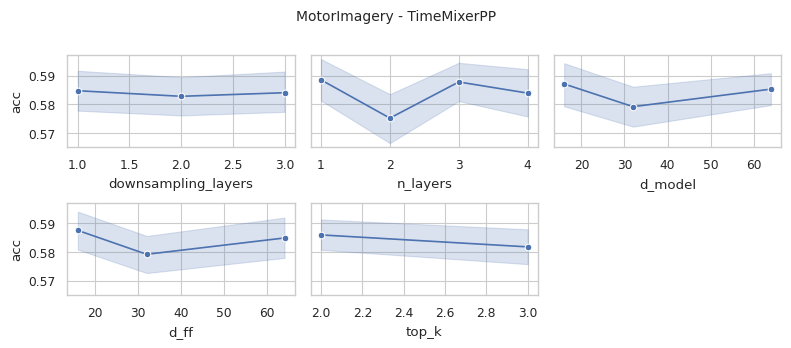

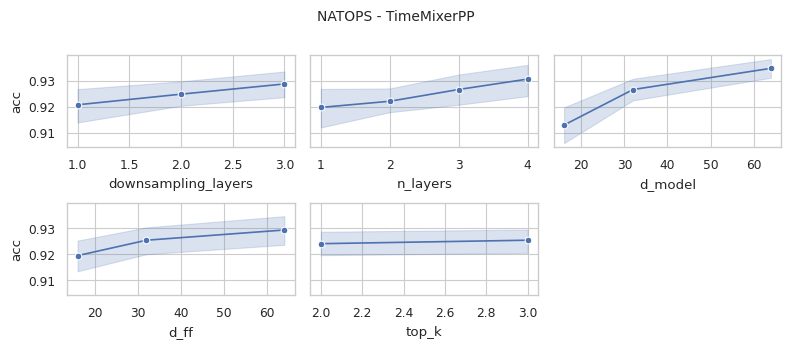

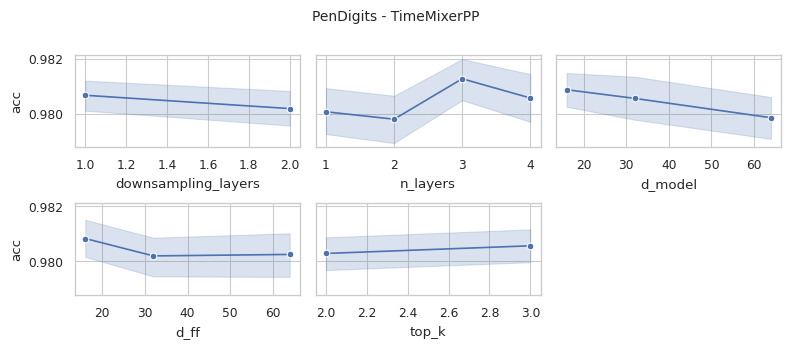

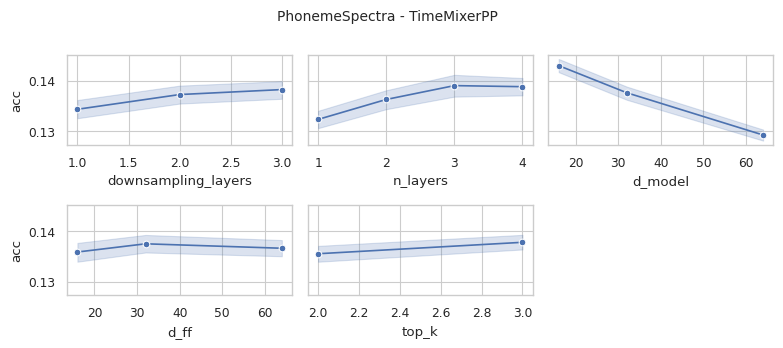

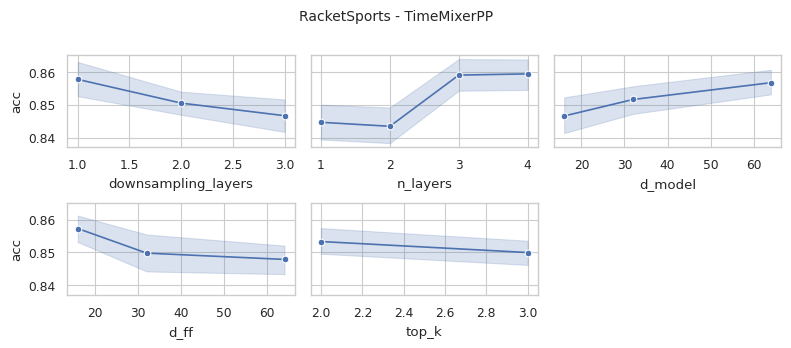

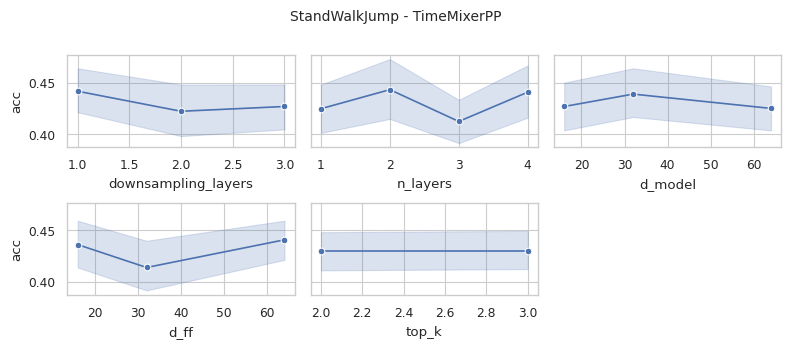

In [4]:
model = 'TimeMixerPP'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = int(data_meta[11].replace('nh', ''))
            data_meta[12] = int(data_meta[12].replace('df', ''))
            data_meta[13] = re.sub(r'(\D+)(\d+)-(\d+)', r'\1,\2,\3', data_meta[13]).split(',')
            data_meta[14] = bool(data_meta[14].replace('cm', ''))
            data_meta[15] = bool(data_meta[15].replace('ci', ''))
            data_meta[16] = bool(data_meta[16].replace('oa', ''))
            data_meta[17] = int(data_meta[17].replace('nk', ''))
            data_meta[18] = int(data_meta[18].replace('tk', ''))



            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'n_layers': data_meta[9],
                'd_model': data_meta[10],
                'n_heads': data_meta[11],
                'd_ff': data_meta[12],
                'downsampling_method': data_meta[13][0],
                'downsampling_layers': int(data_meta[13][1]),
                'downsampling_window': int(data_meta[13][2]),
                # 'channel_mixing': data_meta[14],
                # 'channel_independent': data_meta[15],
                # 'output_attention': data_meta[16],
                # 'num_kernels': data_meta[17],
                'top_k': data_meta[18],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['downsampling_layers', 'n_layers', 'd_model', 'd_ff', 'top_k', ]
    num_cols, num_rows = 3, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    for i in range(len(cols), num_cols*num_rows):
        fig.delaxes(axs[i//num_cols][i%num_cols])
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [5]:
model_configs = {
    "downsampling_method" : ['conv'],
    "downsampling_layers" : [1,2,3],
    "down_sampling_window" : [2],

    "num_kernels" : [6],

    "n_layers" : [1,2,3,4],
    "d_model" : [16,32,64],
    "d_ff" : [16,32,64],
    "top_k" : [2,3],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        downsampling_layers = hyperparameter_combination['downsampling_layers']
        n_layers = hyperparameter_combination['n_layers']
        d_model = hyperparameter_combination['d_model']
        d_ff = hyperparameter_combination['d_ff']
        top_k = hyperparameter_combination['top_k']

        if result_dict.get(data_name) is None:
            continue
        
        if data_name == 'PenDigits' and downsampling_layers == 3:
            print(f'no acc for {data_name} with {hyperparameter_combination} due to short sequence length')
            print(f'instead using acc with 2 downsampling layers')
            downsampling_layers = 2

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['d_model'] == d_model)
                & (tmp['downsampling_layers'] == downsampling_layers)
                & (tmp['n_layers'] == n_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['d_ff'] == d_ff)
                & (tmp['top_k'] == top_k)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



no acc for PenDigits with {'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 16, 'top_k': 2} due to short sequence length
instead using acc with 2 downsampling layers
no acc for PenDigits with {'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 16, 'top_k': 3} due to short sequence length
instead using acc with 2 downsampling layers
no acc for PenDigits with {'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 32, 'top_k': 2} due to short sequence length
instead using acc with 2 downsampling layers
no acc for PenDigits with {'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 32, 'top_k': 3} due to short sequence length
instead using acc

In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 4, 'd_model': 32, 'd_ff': 16, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 64, 'd_ff': 64, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 4, 'd_model': 32, 'd_ff': 16, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 4, 'd_model': 32, 'd_ff': 64, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 2, 'd_model': 32, 'd_ff': 32, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 3, 'd_model': 16, 'd_ff': 64, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 2, 'd_model': 32, 'd_ff': 32, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 2, 'd_model': 16, 'd_ff': 32, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 4, 'd_model': 32, 'd_ff': 64, 'top_k': 3}",...,"{'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 3, 'd_model': 16, 'd_ff': 32, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 64, 'd_ff': 32, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 32, 'd_ff': 16, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 3, 'd_model': 16, 'd_ff': 32, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 2, 'd_model': 16, 'd_ff': 16, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 2, 'd_model': 16, 'd_ff': 16, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 3, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 2, 'd_model': 16, 'd_ff': 16, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 32, 'top_k': 2}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 32, 'top_k': 3}","{'downsampling_method': 'conv', 'downsampling_layers': 2, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 1, 'd_model': 16, 'd_ff': 32, 'top_k': 2}"
EthanolConcentration,0.346008,0.323194,0.288973,0.319392,0.307985,0.292776,0.323194,0.307985,0.285171,0.307985,...,0.319392,0.285171,0.304183,0.315589,0.288973,0.292776,0.292776,0.323194,0.273764,0.273764
FaceDetection,0.696652,0.671396,0.66941,0.681896,0.670261,0.671964,0.685868,0.681044,0.681328,0.674801,...,0.687571,0.66941,0.67849,0.696368,0.677923,0.674518,0.680193,0.683314,0.683314,0.69126
Handwriting,0.336471,0.298824,0.289412,0.305882,0.290588,0.270588,0.298824,0.269412,0.292941,0.294118,...,0.250588,0.278824,0.274118,0.262353,0.275294,0.283529,0.26,0.292941,0.292941,0.274118
Heartbeat,0.804878,0.765854,0.785366,0.77561,0.780488,0.770732,0.75122,0.770732,0.770732,0.785366,...,0.765854,0.760976,0.760976,0.760976,0.75122,0.746341,0.746341,0.765854,0.77561,0.770732
JapaneseVowels,0.991892,0.972973,0.975676,0.97027,0.981081,0.967568,0.978378,0.967568,0.975676,0.978378,...,0.97027,0.959459,0.97027,0.97027,0.967568,0.954054,0.954054,0.945946,0.951351,0.9

In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'downsampling_method': 'conv', 'downsampling_layers': 1, 'down_sampling_window': 2, 'num_kernels': 6, 'n_layers': 4, 'd_model': 32, 'd_ff': 16, 'top_k': 2}"
EthanolConcentration,34.60076045627377,32.31939163498099
FaceDetection,69.66515323496027,67.13961407491486
Handwriting,33.64705882352941,29.88235294117647
Heartbeat,80.48780487804879,76.58536585365854
JapaneseVowels,99.18918918918919,97.29729729729731
PEMS-SF,89.01734104046243,84.39306358381504
SelfRegulationSCP1,92.15017064846417,90.10238907849829
SelfRegulationSCP2,60.55555555555555,55.00000000000001
SpokenArabicDigits,99.54524783992724,98.59026830377444
UWaveGestureLibrary,90.625,85.9375
